# Models analyses

Import models and testing set

In [68]:
import pickle
from pathlib import Path

model_paths = {
    "RF no-odds": Path("../models/rf_no_odds_model.pkl"),
    "RF with-odds": Path("../models/rf_with_odds_model.pkl"),
    "XGB no-odds": Path("../models/xgb_no_odds_model.pkl"),
    "XGB with-odds": Path("../models/xgb_with_odds_model.pkl"),
}

models = {}
for name, path in model_paths.items():
    with open(path, "rb") as f:
        models[name] = pickle.load(f)


In [69]:
import numpy as np, pandas as pd
from IPython.display import display

TESTING_PATH = "../data/testing/tennis_testing.xlsx"

test_set = pd.read_excel(TESTING_PATH)

target = "y"
y_test = test_set[target]

print(f"Loaded prepared test set with {len(test_set)} rows")


Loaded prepared test set with 16482 rows


### Baselines

In [70]:
def baseline_accuracy(name, prediction, valid_mask, y_test):
    """Accuracy of a prediction rule, computed only on matches where it applies."""
    accuracy = (prediction[valid_mask] == y_test[valid_mask]).mean()
    coverage = valid_mask.mean()
    print(f"{name}: {accuracy:.2%}  (coverage: {coverage:.1%})")


# Majority class: whichever class (0 or 1) is more common in the test set.
maj_acc = y_test.value_counts().max() / y_test.value_counts().sum()
print(f"Majority class: {maj_acc:.2%}")

baseline_accuracy("Ranking", test_set["Rank_Log_Ratio"] > 0, test_set["Rank_Log_Ratio"].notna(), y_test)
baseline_accuracy("Points", test_set["Points_Log_Ratio"] > 0, test_set["Points_Log_Ratio"].notna(), y_test)

valid_odds = test_set["Odds_1"].notna() & test_set["Odds_2"].notna() & (test_set["Odds_1"] != test_set["Odds_2"])
baseline_accuracy("Market (odds)", test_set["Odds_1"] < test_set["Odds_2"], valid_odds, y_test)


Majority class: 50.16%
Ranking: 63.65%  (coverage: 99.8%)
Points: 63.38%  (coverage: 99.8%)
Market (odds): 68.51%  (coverage: 97.1%)


### Model Evaluation

In [71]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
    brier_score_loss,
    f1_score,
)

def get_model_data(model, test_set):
    model_features = list(model.feature_names_in_)
    X = test_set[model_features]
    y = test_set["y"]
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return model_features, X, y, proba, pred

def evaluate_model(name, model, test_set):
    model_features, X, y, proba, pred = get_model_data(model, test_set)

    metrics = {
        "Accuracy": accuracy_score(y, pred),
        "F1-Score": f1_score(y, pred),
        "ROC AUC": roc_auc_score(y, proba),
        "Log loss": log_loss(y, proba),
        "Brier Score": brier_score_loss(y, proba),
    }

    return {
        "name": name,
        "features": model_features,
        "X": X,
        "y": y,
        "proba": proba,
        "pred": pred,
        "metrics": metrics,
    }

results = {name: evaluate_model(name, model, test_set) for name, model in models.items()}

results_df = pd.DataFrame({name: r["metrics"] for name, r in results.items()}).T
display(results_df)

,Accuracy,F1-Score,ROC AUC,Log loss,Brier Score
RF no-odds,0.651256,0.647145,0.714686,0.616408,0.214586
RF with-odds,0.672249,0.668914,0.741770,0.595925,0.205517
XGB no-odds,0.652955,0.649853,0.717805,0.614641,0.213832
XGB with-odds,0.679711,0.679458,0.746662,0.593121,0.204042


### Feature Usage

In [72]:
def source_feature_name(transformed_name, model_features):
    # Map transformed one-hot and missing-indicator names back to source columns.
    if transformed_name.startswith("num__missingindicator_"):
        return transformed_name.removeprefix("num__missingindicator_")
    if transformed_name.startswith("num__"):
        return transformed_name.removeprefix("num__")
    if transformed_name.startswith("cat__"):
        encoded = transformed_name.removeprefix("cat__")
    elif transformed_name.startswith("high_cardinality__"):
        encoded = transformed_name.removeprefix("high_cardinality__")
    else:
        return transformed_name

    for feature in model_features:
        if encoded.startswith(f"{feature}_"):
            return feature
    return encoded


def feature_usage(name, model, top_n=15):
    model_features = list(model.feature_names_in_)
    transformed_names = model[:-1].get_feature_names_out()
    estimator = model.named_steps["model"]

    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
        column = "Importance"
    else:
        values = np.abs(estimator.coef_[0])
        column = "Abs_Coefficient"

    usage = pd.DataFrame({"Feature": transformed_names, column: values})
    usage["Source_Feature"] = usage["Feature"].map(
        lambda feature: source_feature_name(feature, model_features)
    )

    usage_by_source = (
        usage.groupby("Source_Feature", as_index=False)[column]
        .sum()
        .sort_values(column, ascending=False)
    )

    print(f"{name} feature usage")
    display(usage_by_source.head(top_n))

for name, model in models.items():
    feature_usage(name, model)


RF no-odds feature usage


,Source_Feature,Importance
13,Surface_Elo_Diff,0.296016
7,Points_Diff,0.201636
8,Rank_Diff,0.187624
2,Dominance_Form_Diff,0.160639
9,Recent_Surface_Form_Diff,0.045271
3,Fatigue_Diff,0.026798
0,Age_Diff,0.022370
11,Series,0.016541
4,H2H_Surface_Diff,0.013766
10,Round,0.012160


RF with-odds feature usage


,Source_Feature,Importance
7,Odds_Diff,0.377765
14,Surface_Elo_Diff,0.183432
8,Points_Diff,0.130858
9,Rank_Diff,0.102963
2,Dominance_Form_Diff,0.095335
10,Recent_Surface_Form_Diff,0.030836
3,Fatigue_Diff,0.019215
0,Age_Diff,0.016514
12,Series,0.011697
4,H2H_Surface_Diff,0.010232


XGB no-odds feature usage


,Source_Feature,Importance
13,Surface_Elo_Diff,0.293123
10,Round,0.139409
11,Series,0.127973
7,Points_Diff,0.097333
8,Rank_Diff,0.057197
12,Surface,0.055316
2,Dominance_Form_Diff,0.044493
0,Age_Diff,0.036150
6,Home_Advantage,0.035212
5,Hand_Advantage,0.029695


XGB with-odds feature usage


,Source_Feature,Importance
7,Odds_Diff,0.452718
14,Surface_Elo_Diff,0.378350
8,Points_Diff,0.115403
2,Dominance_Form_Diff,0.053529
0,Age_Diff,0.000000
1,Court,0.000000
3,Fatigue_Diff,0.000000
4,H2H_Surface_Diff,0.000000
5,Hand_Advantage,0.000000
6,Home_Advantage,0.000000


### Feature distribution

In [73]:
def plot_feature_distribution(name, res, test_set):
    comparison_df = pd.DataFrame({
        "Correct": res["pred"] == res["y"],
        "Surface_Elo_Diff": test_set["Surface_Elo_Diff"],
        "Odds_Diff": test_set["Odds_Diff"],
        "Ranking_Diff": test_set["Rank_Diff"]
    })
    
    print(f"\n--- {name}: Feature Distribution (Correct vs Wrong) ---")
    display(comparison_df.groupby("Correct")[["Surface_Elo_Diff", "Odds_Diff", "Ranking_Diff"]].describe())
    
# for name, res in results.items():
    # plot_feature_distribution(name, res, test_set)
    
plot_feature_distribution("XGB no-odds", results["XGB no-odds"], test_set)


--- XGB no-odds: Feature Distribution (Correct vs Wrong) ---


Surface_Elo_Diff                                                \
                   count      mean         std         min         25%   
Correct                                                                  
False             5720.0  2.162244  152.641264 -742.985719  -94.309980   
True             10762.0  0.469780  214.979136 -818.906305 -144.819156   

                                          Odds_Diff                      \
              50%         75%         max     count      mean       std   
Correct                                                                   
False    3.910198  100.276985  628.064451    5689.0 -0.027277  1.969226   
True     0.272519  149.824761  799.247701   10722.0  0.028859  4.972919   

                                       Ranking_Diff                        \
           min   25%  50%   75%    max        count      mean         std   
Correct                                                                     
False   -27.99 -0.97  0.0  0.83  21.99       5711.0 -1.802311  104.740598   
True    -66.00 -1.84  0.0  1.60  66.00      10740.0 -1.714991  168.238025   

                                          
            min   25%  50%   75%     max  
Correct                                   
False   -1093.0 -36.0 -2.0  34.0  1162.0  
True    -3381.0 -44.0 -1.0  44.0  4911.0

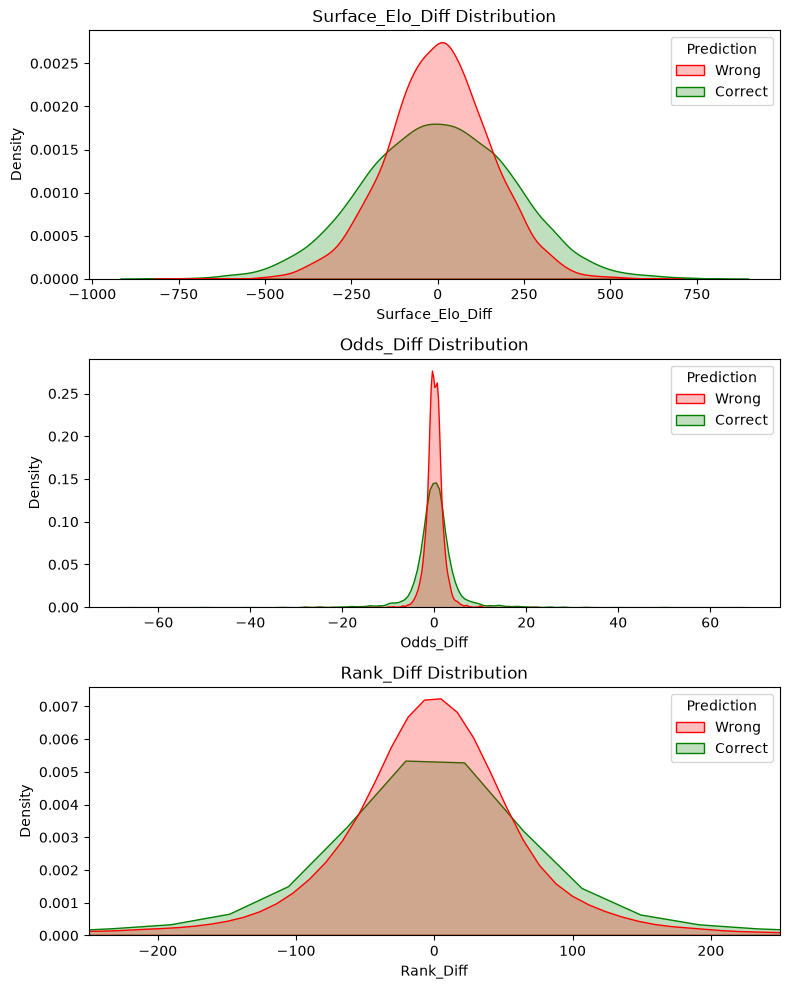

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

res = results["XGB no-odds"]

comp_df = pd.DataFrame({
    "Prediction": ["Correct" if p == y else "Wrong" for p, y in zip(res["pred"], res["y"])],
    "Surface_Elo_Diff": test_set["Surface_Elo_Diff"],
    "Odds_Diff": test_set["Odds_Diff"],
    "Rank_Diff": test_set["Rank_Diff"],
    "Surface": test_set["Surface"],  
    "Series": test_set["Series"]     
})

features = ["Surface_Elo_Diff", "Odds_Diff", "Rank_Diff"]
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for ax, feat in zip(axes, features):
    sns.kdeplot(
        data=comp_df,
        x=feat,
        hue="Prediction",
        fill=True,
        common_norm=False,
        palette={"Correct": "green", "Wrong": "red"},
        ax=ax
    )
    ax.set_title(f"{feat} Distribution")
    ax.set_ylabel("Density")
    
    # Zoom in on Rank_Diff to remove extreme outliers
    if feat == "Rank_Diff":
        ax.set_xlim(-250, 250)

plt.tight_layout()
plt.show()

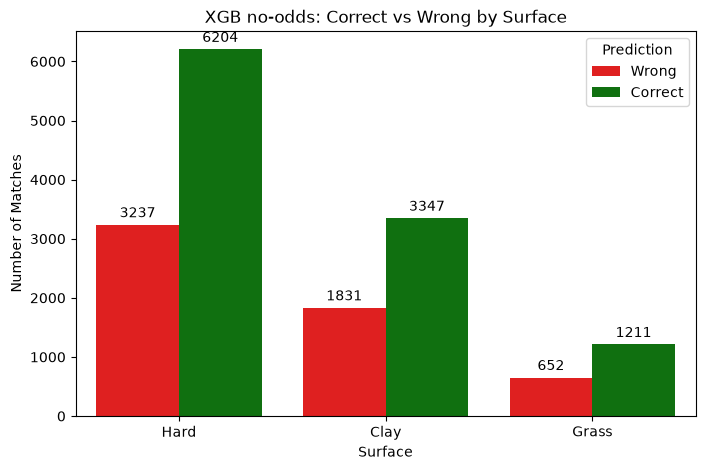

--- Accuracy by Surface ---
Surface
Hard     65.71%
Grass     65.0%
Clay     64.64%
Name: Correct, dtype: str




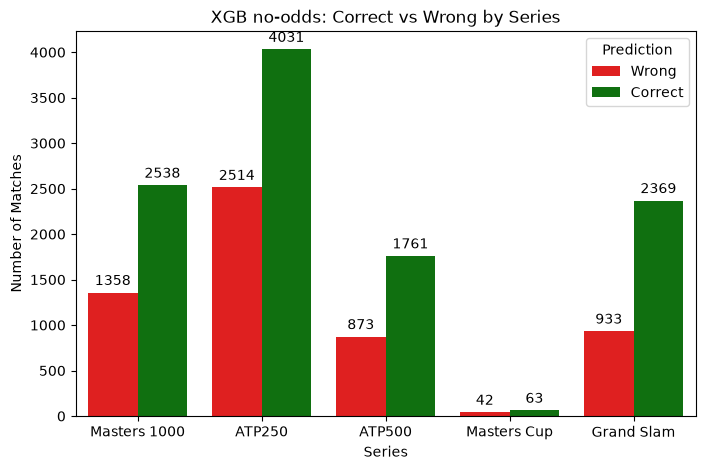

--- Accuracy by Series ---
Series
Grand Slam      71.74%
ATP500          66.86%
Masters 1000    65.14%
ATP250          61.59%
Masters Cup      60.0%
Name: Correct, dtype: str




In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Grafici a barre per le feature categoriche con NUMERI ESATTI
categorical_feats = ["Surface", "Series"]
for feat in categorical_feats:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=comp_df, x=feat, hue="Prediction", palette={"Correct": "green", "Wrong": "red"})
    
    # Questo ciclo aggiunge il numero esatto sopra le barre
    for container in ax.containers:
        ax.bar_label(container, padding=3, fmt='%d')
        
    plt.title(f"XGB no-odds: Correct vs Wrong by {feat}")
    plt.xlabel(feat)
    plt.ylabel("Number of Matches")
    plt.show()

    # Calcolo extra: stampa l'accuratezza per ogni categoria
    print(f"--- Accuracy by {feat} ---")
    accuracy_df = comp_df.groupby(feat)['Prediction'].value_counts(normalize=True).unstack() * 100
    if 'Correct' in accuracy_df.columns:
        print(accuracy_df['Correct'].sort_values(ascending=False).round(2).astype(str) + '%')
    print("\n")

## Most Confident Wrong Matches

In [76]:
def show_most_wrong(name, results, test_set, top_n=10):
    """Show the model's most confident WRONG predictions — useful to spot where it fails."""
    predicted_player_1 = results["pred"] == 1

    wrong = pd.DataFrame({
        "Actual_Winner": np.where(results["y"] == 1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Winner": np.where(predicted_player_1, test_set["Player_1"], test_set["Player_2"]),
        "P1": test_set["Player_1"],
        "P2": test_set["Player_2"],
        "Rank_Diff": test_set["Rank_Diff"],
        "Rank1": test_set["Rank_1"],
        "Rank2": test_set["Rank_2"],
        "Surface_Elo_Diff": test_set["Surface_Elo_Diff"],
        # "Odds_Diff": test_set["Odds_Diff"],
        "Confidence": np.where(predicted_player_1, results["proba"], 1 - results["proba"]),
        "Date": test_set["Date"],
    }, index=test_set.index)

    wrong = wrong[results["y"] != results["pred"]]
    wrong = wrong.sort_values("Confidence", ascending=False).head(top_n)

    print(f"{name}: most confident wrong matches")
    display(wrong)


pd.set_option("display.max_columns", None)

# for name, model in models.items():
    # show_most_wrong(name, results[name], test_set)
    
show_most_wrong("XGB no-odds", results["XGB no-odds"], test_set, 5)

XGB no-odds: most confident wrong matches


,Actual_Winner,Predicted_Winner,P1,P2,Rank_Diff,Rank1,Rank2,Surface_Elo_Diff,Confidence,Date
10033,nardi l.,djokovic n.,nardi l.,djokovic n.,122.0,123.0,1.0,-742.985719,0.967220,2024-03-12
14405,griekspoor t.,sinner j.,griekspoor t.,sinner j.,29.0,31.0,2.0,-525.832618,0.966135,2025-10-05
15950,cerundolo j.m.,sinner j.,sinner j.,cerundolo j.m.,-55.0,1.0,56.0,581.955845,0.964407,2026-05-28
4589,vesely j.,djokovic n.,vesely j.,djokovic n.,122.0,123.0,1.0,-674.833960,0.956158,2022-02-24
7950,seyboth wild t.,medvedev d.,seyboth wild t.,medvedev d.,170.0,172.0,2.0,-350.281449,0.952393,2023-05-30


### Most correct matches

In [77]:
def show_most_correct(name, results, test_set, top_n=10):
    """Show the model's most confident CORRECT predictions."""
    predicted_player_1 = results["pred"] == 1

    correct = pd.DataFrame({
        "Actual_Winner": np.where(results["y"] == 1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Winner": np.where(predicted_player_1, test_set["Player_1"], test_set["Player_2"]),
        "P1": test_set["Player_1"],
        "P2": test_set["Player_2"],
        "Ranking_Diff": test_set["Rank_Diff"],
        "Confidence": np.where(predicted_player_1, results["proba"], 1 - results["proba"]),
        "Surface_Elo_Diff": test_set["Surface_Elo_Diff"],
        # "Odds_Diff": test_set["Odds_Diff"],
        "Date": test_set["Date"],
    }, index=test_set.index)

    correct = correct[results["y"] == results["pred"]]
    correct = correct.sort_values("Confidence", ascending=False).head(top_n)

    print(f"{name}: most confident correct matches")
    display(correct)


pd.set_option("display.max_columns", None)

# for name, model in models.items():
    # show_most_correct(name, results[name], test_set)
    
show_most_correct("XGB no-odds", results["XGB no-odds"], test_set, 5)

XGB no-odds: most confident correct matches


,Actual_Winner,Predicted_Winner,P1,P2,Ranking_Diff,Confidence,Surface_Elo_Diff,Date
1193,djokovic n.,djokovic n.,berankis r.,djokovic n.,65.0,0.983316,-675.017175,2020-10-01
1158,djokovic n.,djokovic n.,ymer m.,djokovic n.,79.0,0.982787,-560.239198,2020-09-29
1175,nadal r.,nadal r.,mcdonald m.,nadal r.,234.0,0.982488,-782.066825,2020-09-30
376,nadal r.,nadal r.,dellien h.,nadal r.,72.0,0.981917,-600.912506,2020-01-21
8813,djokovic n.,djokovic n.,zapata miralles b.,djokovic n.,74.0,0.981722,-757.612023,2023-08-30


Testing accuracy for best ranking players

In [78]:
market_pred = (test_set["Odds_1"] < test_set["Odds_2"]).to_numpy()
market_valid = test_set["Odds_1"].notna() & test_set["Odds_2"].notna()

for top_n in [10, 50, 100]:
    both_top = (test_set["Rank_1"] <= top_n) & (test_set["Rank_2"] <= top_n)
    mask = both_top & market_valid
    
    market_acc = (market_pred[mask] == y_test[mask]).mean()
    print(f"\n--- Top {top_n} (n={mask.sum()}) | Market: {market_acc:.2%} ---")
    
    # Iterate through all evaluated models
    for name, res in results.items():
        model_acc = (res["pred"][mask] == y_test[mask]).mean()
        print(f"{name}: {model_acc:.2%}")


--- Top 10 (n=353) | Market: 65.16% ---
RF no-odds: 64.02%
RF with-odds: 64.59%
XGB no-odds: 63.17%
XGB with-odds: 65.16%

--- Top 50 (n=4002) | Market: 68.09% ---
RF no-odds: 66.32%
RF with-odds: 67.24%
XGB no-odds: 66.02%
XGB with-odds: 68.19%

--- Top 100 (n=10341) | Market: 67.51% ---
RF no-odds: 65.14%
RF with-odds: 66.86%
XGB no-odds: 65.11%
XGB with-odds: 67.37%


Testing accuracy for Grand Slam tournaments

In [79]:
grand_slam_mask = (test_set["Series"] == "Grand Slam") & market_valid

market_acc_gs = (market_pred[grand_slam_mask] == y_test[grand_slam_mask]).mean()
print(f"--- Grand Slam (n={grand_slam_mask.sum()}) | Market: {market_acc_gs:.2%} ---")

for name, res in results.items():
    model_acc_gs = (res["pred"][grand_slam_mask] == y_test[grand_slam_mask]).mean()
    print(f"{name}: {model_acc_gs:.2%}")

--- Grand Slam (n=3299) | Market: 74.33% ---
RF no-odds: 71.39%
RF with-odds: 73.60%
XGB no-odds: 71.75%
XGB with-odds: 74.48%
